In [ ]:
#It reviews how the model predicts the next character based on only one previous character, 
#using counts normalized into probability distributions. While this approach is straightforward and computationally simple,
#its main limitation is poor prediction quality due to the limited context, 
#resulting in less realistic or natural-sounding output.

#Context size explosion in bigram model

#The explanation focuses on the challenge of predicting the next character in a sequence using context. 
#The size of the matrix representing all possible contexts grows exponentially with the length of the context 
#because each additional character multiplies the number of possibilities (e.g., 27 characters lead to 27 
#possibilities, two characters lead to 729, and three characters jump to about 20,000). 
#This exponential growth results in too many matrix rows with insufficient data counts for reliable predictions, 
#causing the method to fail. To address this, the discussion transitions to implementing a multi-layer perceptron model 
#as a more effective approach for predicting the next character, based on a referenced paper.



In [ ]:
#The discussion begins with a reference to Bengio et al. 2003, a seminal and often-cited paper on neural networks for
#predicting the next character or token in a sequence. Although the paper focuses on a word-level language model with a 
#vocabulary of 17,000 words, the speaker emphasizes that their approach will remain character-level but inspired by the same modeling ideas.
#The paper introduces the concept of embedding each word into a 30-dimensional feature vector space, where initially these 
#embeddings are randomly assigned but then refined through backpropagation during training. This results in words with similar 
#meanings being mapped close to each other in this multi-dimensional space.

#https://jmlr.org/papers/volume3/bengio03a/bengio03a.pdf

In [ ]:
#The model employs a multilayer neural network trained to maximize the log likelihood of the training data, 
#identical to the speaker’s approach. An example illustrates how the model generalizes to unseen phrases by 
#leveraging embeddings: even if an exact phrase like 'a dog was running in a' is not in the training data, similar 
#phrases and related embeddings such as 'a' and 'the' or 'cats' and 'dogs' being close in embedding space help the 
#model predict plausible next words. This embedding space thus enables transfer of knowledge to novel, out-of-distribution inputs.
#The segment concludes by pointing to a network diagram showing prediction of the next word based on three preceding words.


In [ ]:
#Neural network architecture details
#The segment explains how words in a sequence are represented as indices in a vocabulary of 17,000 words. 
#Each word index is used to look up a corresponding 30-dimensional embedding vector from a fixed embedding matrix. 
#For three input words, the input layer has 90 neurons (3 words × 30 dimensions). 
#This embedding matrix is shared across all words, ensuring consistent representation.
#The discussion continues with the introduction of the hidden layer in the neural network, 
#whose size is a hyperparameter chosen by the designer. For example, a hidden layer could have 100 neurons. 
#This hidden layer is fully connected to all 90 input neurons derived from the three word embeddings, forming a dense network layer.
#Following the hidden layer, there is a linear transformation and an output layer consisting of 17,000 neurons, 
#each corresponding to a possible next word. All neurons in the hidden layer connect fully to the output layer, 
#making this the computationally expensive part of the network. A softmax layer converts the 17,000 logits to 
#probabilities representing the likelihood of each next word.
#During training, the actual next word label is used to extract the corresponding predicted 
#probability from the softmax output. The network parameters—including weights, biases of the output and hidden layers, 
#and the embedding matrix—are adjusted to
#maximize this probability. This optimization is done via backpropagation.


In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [ ]:
#Dataset creation and block size explanation
#The segment explains the initial steps of preparing a dataset for a neural network. 
#It starts by building a vocabulary of characters and mapping them to integers. 
#The concept of 'block size' is introduced, which defines the context length used 
#to predict the next character. In the example, three characters are used to predict 
#the fourth, and the input (x) and labels (y) for the neural network are constructed accordingly.


In [11]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:
  
  print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [13]:

X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [14]:
#This part demonstrates how the dataset is created by iterating over example words, 
#showing how inputs and labels correspond using a sliding window of context characters. 
#The example uses padding with zero tokens and explains how each character sequence is 
#segmented to prepare inputs and outputs for training. Modifying the block size changes 
#the context window, affecting which next character is predicted.

In [15]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [16]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [ ]:
#After creating the dataset with inputs of three-character sequences and corresponding labels,
#the focus shifts to building an embedding lookup table for the 27 possible characters. 
#Inspired by a paper embedding 17,000 words into a 30-dimensional space, 
#here characters are embedded into a much smaller 2-dimensional space. 
#This results in a matrix of random initialization that will serve as the embedding layer 
#in the neural network.


In [25]:

C = torch.randn((27, 2))

In [26]:
C

tensor([[-0.4174,  1.0101],
        [ 0.4478,  0.2134],
        [-1.3657, -0.0526],
        [ 0.3581,  0.9032],
        [ 1.9852,  0.2183],
        [ 1.3736, -1.0460],
        [-2.2205, -0.8466],
        [-1.2224,  0.3156],
        [-0.4801,  0.4110],
        [-1.6676,  1.6571],
        [-0.3298,  1.6237],
        [ 0.0519,  1.5147],
        [ 0.4135, -1.1486],
        [ 0.7175,  0.9395],
        [-1.1057, -0.3703],
        [-1.0127,  0.8569],
        [ 0.4040,  0.2699],
        [-0.5872, -1.1189],
        [-0.3873,  0.7848],
        [-0.0832, -1.8485],
        [-0.7912, -0.8604],
        [ 0.7532,  0.2858],
        [ 0.2079,  0.6241],
        [-0.3443,  1.2580],
        [-0.5387, -1.2690],
        [ 0.0516,  2.1406],
        [-2.1602,  0.8928]])

In [27]:
#The embedding process for individual characters is illustrated using integer indexing into the
#embedding matrix. An alternative approach using one-hot encoding is introduced. 
#However, this approach initially causes errors because the input tensor types are 
#incompatible. The segment discusses these intentional coding challenges to illustrate 
#common debugging steps when working with embeddings and tensor operations.


In [28]:
C[5]

tensor([ 1.3736, -1.0460])

In [29]:
F.one_hot(torch.tensor(5),num_classes=27)

tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])

In [30]:
F.one_hot(torch.tensor(5),num_classes=27).shape

torch.Size([27])

In [31]:
F.one_hot(torch.tensor(5),num_classes=27).dtype

torch.int64

In [33]:
F.one_hot(torch.tensor(5),num_classes=27).float() @ C
#The solution to the tensor type mismatch is casting the one-hot encoded vector to a 
#float to enable multiplication with the embedding matrix. This multiplication 
#effectively extracts the desired embedding vector. The explanation highlights that 
#indexing into an embedding lookup table and multiplying a one-hot vector by the embedding 
#matrix are mathematically equivalent. This equivalence also leads to an interpretation of 
#the embedding as the first linear layer of the neural network.


tensor([ 1.3736, -1.0460])

In [34]:
#Embedding lookup and indexing techniques
#The speaker explains embedding integer inputs in PyTorch by indexing embedding tables.
#PyTorch allows flexible indexing not just with single integers but also with lists or 
#integer tensors, including multi-dimensional tensors. This capability enables simultaneous 
#embedding of all integers in a 32 by 3 tensor efficiently by simply indexing with that 
#tensor.

C[[5,6,7]]

tensor([[ 1.3736, -1.0460],
        [-2.2205, -0.8466],
        [-1.2224,  0.3156]])

In [36]:
C[torch.tensor([5,6,7])]


tensor([[ 1.3736, -1.0460],
        [-2.2205, -0.8466],
        [-1.2224,  0.3156]])

In [37]:
C[torch.tensor([5,6,7,7,7,7])]

tensor([[ 1.3736, -1.0460],
        [-2.2205, -0.8466],
        [-1.2224,  0.3156],
        [-1.2224,  0.3156],
        [-1.2224,  0.3156],
        [-1.2224,  0.3156]])

In [38]:
C[X]

tensor([[[-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [-0.4174,  1.0101]],

        [[-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [ 1.3736, -1.0460]],

        [[-0.4174,  1.0101],
         [ 1.3736, -1.0460],
         [ 0.7175,  0.9395]],

        [[ 1.3736, -1.0460],
         [ 0.7175,  0.9395],
         [ 0.7175,  0.9395]],

        [[ 0.7175,  0.9395],
         [ 0.7175,  0.9395],
         [ 0.4478,  0.2134]],

        [[-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [-0.4174,  1.0101]],

        [[-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [-1.0127,  0.8569]],

        [[-0.4174,  1.0101],
         [-1.0127,  0.8569],
         [ 0.4135, -1.1486]],

        [[-1.0127,  0.8569],
         [ 0.4135, -1.1486],
         [-1.6676,  1.6571]],

        [[ 0.4135, -1.1486],
         [-1.6676,  1.6571],
         [ 0.2079,  0.6241]],

        [[-1.6676,  1.6571],
         [ 0.2079,  0.6241],
         [-1.6676,  1.6571]],

        [[ 0.2079,  0

In [ ]:
#Using an example, the speaker demonstrates verifying the correctness of embedding 
#lookups by comparing direct indexing to the embedding results. Then, the focus shifts 
#to constructing a hidden layer with random weights and biases. The input size to this 
#layer is calculated based on embedding dimensions and the number of tokens, highlighting 
#the challenge of performing matrix multiplication directly on the 
#higher-dimensional embedding tensor.

In [40]:
C[X].shape
#The problem of incompatible shapes for matrix multiplication with a 32 by 3 by 2 embedding 
#tensor is addressed. The need to concatenate embeddings into a 32 by 6 tensor is 
#introduced. The speaker discusses PyTorch's extensive functionality and points out 
#the torch.cat function, which concatenates
#tensors along a specified dimension, as a potential solution.

torch.Size([32, 3, 2])

In [41]:
X[13,2]

tensor(1)

In [42]:
C[X][13,2]

tensor([0.4478, 0.2134])

In [43]:
C[1]

tensor([0.4478, 0.2134])

In [44]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [45]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)
#The problem of incompatible shapes for matrix multiplication with a 32 by 3 by 2
#embedding tensor is addressed. The need to concatenate embeddings into a 32 by 6 
#tensor is introduced. The speaker discusses PyTorch's extensive functionality and 
#points out the torch.cat function, which concatenates 
#tensors along a specified dimension, as a potential solution.
#emb @ w1 + b1 will not work 

In [46]:
emb[:,0,:]

tensor([[-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [ 1.3736, -1.0460],
        [ 0.7175,  0.9395],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-1.0127,  0.8569],
        [ 0.4135, -1.1486],
        [-1.6676,  1.6571],
        [ 0.2079,  0.6241],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [ 0.4478,  0.2134],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-1.6676,  1.6571],
        [-0.0832, -1.8485],
        [ 0.4478,  0.2134],
        [-1.3657, -0.0526],
        [ 1.3736, -1.0460],
        [ 0.4135, -1.1486],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.0832, -1.8485],
        [-1.0127,  0.8569],
        [ 0.4040,  0.2699],
        [-0.4801,  0.4110]])

In [51]:
torch.cat([emb[:,0,:] , emb[:,1,:] ,emb[:,2,:]],)

tensor([[-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [ 1.3736, -1.0460],
        [ 0.7175,  0.9395],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-1.0127,  0.8569],
        [ 0.4135, -1.1486],
        [-1.6676,  1.6571],
        [ 0.2079,  0.6241],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [ 0.4478,  0.2134],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-1.6676,  1.6571],
        [-0.0832, -1.8485],
        [ 0.4478,  0.2134],
        [-1.3657, -0.0526],
        [ 1.3736, -1.0460],
        [ 0.4135, -1.1486],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.0832, -1.8485],
        [-1.0127,  0.8569],
        [ 0.4040,  0.2699],
        [-0.4801,  0.4110],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [ 1.3736, -1.0460],
        [ 0.7175,  0

In [52]:
torch.cat([emb[:,0,:] , emb[:,1,:] ,emb[:,2,:]],1)

tensor([[-0.4174,  1.0101, -0.4174,  1.0101, -0.4174,  1.0101],
        [-0.4174,  1.0101, -0.4174,  1.0101,  1.3736, -1.0460],
        [-0.4174,  1.0101,  1.3736, -1.0460,  0.7175,  0.9395],
        [ 1.3736, -1.0460,  0.7175,  0.9395,  0.7175,  0.9395],
        [ 0.7175,  0.9395,  0.7175,  0.9395,  0.4478,  0.2134],
        [-0.4174,  1.0101, -0.4174,  1.0101, -0.4174,  1.0101],
        [-0.4174,  1.0101, -0.4174,  1.0101, -1.0127,  0.8569],
        [-0.4174,  1.0101, -1.0127,  0.8569,  0.4135, -1.1486],
        [-1.0127,  0.8569,  0.4135, -1.1486, -1.6676,  1.6571],
        [ 0.4135, -1.1486, -1.6676,  1.6571,  0.2079,  0.6241],
        [-1.6676,  1.6571,  0.2079,  0.6241, -1.6676,  1.6571],
        [ 0.2079,  0.6241, -1.6676,  1.6571,  0.4478,  0.2134],
        [-0.4174,  1.0101, -0.4174,  1.0101, -0.4174,  1.0101],
        [-0.4174,  1.0101, -0.4174,  1.0101,  0.4478,  0.2134],
        [-0.4174,  1.0101,  0.4478,  0.2134,  0.2079,  0.6241],
        [ 0.4478,  0.2134,  0.2079,  0.6

In [53]:
torch.cat([emb[:,0,:] , emb[:,1,:] ,emb[:,2,:]],1).shape

torch.Size([32, 6])

In [54]:
#The method to extract individual embedding slices and concatenate them using torch.cat 
#along the correct dimension is explained. This produces the desired 32 by 6 tensor. 
#However, the speaker notes this approach is hard-coded for a specific number of inputs 
#and introduces torch.unbind as a general solution to dynamically remove a tensor dimension,
#returning slices that can be concatenated without fixed indexing.
torch.unbind(emb,1)

(tensor([[-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [ 1.3736, -1.0460],
         [ 0.7175,  0.9395],
         [-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [-1.0127,  0.8569],
         [ 0.4135, -1.1486],
         [-1.6676,  1.6571],
         [ 0.2079,  0.6241],
         [-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [ 0.4478,  0.2134],
         [-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [-1.6676,  1.6571],
         [-0.0832, -1.8485],
         [ 0.4478,  0.2134],
         [-1.3657, -0.0526],
         [ 1.3736, -1.0460],
         [ 0.4135, -1.1486],
         [-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [-0.0832, -1.8485],
         [-1.0127,  0.8569],
         [ 0.4040,  0.2699],
         [-0.4801,  0.4110]]),
 tensor([[-0.4174,  1.0101],
         [-0.4174,  1.0101],
         [ 1

In [56]:
len(torch.unbind(emb,1))

3

In [57]:
torch.cat(torch.unbind(emb,1))

tensor([[-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [ 1.3736, -1.0460],
        [ 0.7175,  0.9395],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-1.0127,  0.8569],
        [ 0.4135, -1.1486],
        [-1.6676,  1.6571],
        [ 0.2079,  0.6241],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [ 0.4478,  0.2134],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-1.6676,  1.6571],
        [-0.0832, -1.8485],
        [ 0.4478,  0.2134],
        [-1.3657, -0.0526],
        [ 1.3736, -1.0460],
        [ 0.4135, -1.1486],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [-0.0832, -1.8485],
        [-1.0127,  0.8569],
        [ 0.4040,  0.2699],
        [-0.4801,  0.4110],
        [-0.4174,  1.0101],
        [-0.4174,  1.0101],
        [ 1.3736, -1.0460],
        [ 0.7175,  0

In [59]:
torch.cat(torch.unbind(emb,1),1).shape

#same as torch.cat([emb[:,0,:] , emb[:,1,:] ,emb[:,2,:]],1).shape

torch.Size([32, 6])

In [62]:
#The speaker continues by showing how torch.unbind combined with torch.cat can 
#generalize concatenation for any block size, making the code more flexible. 
#Then, they introduce a more efficient method using the tensor.view function to 
#reshape tensors without copying data, foreshadowing its use for concatenating 
#embeddings by logically changing tensor dimensions.
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [63]:
a.shape

torch.Size([18])

In [64]:
a.view(2,9)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])

In [66]:
a.view(3,3,2)
#The internal mechanics of PyTorch tensors are discussed, focusing on how the view operation 
#reinterprets the underlying one-dimensional storage as higher-dimensional tensors 
#without creating copies. This is highly efficient because only tensor metadata like shape, 
#strides, and storage offset are modified, not the actual memory. 
#A referenced blog post provides deeper insights into these internals.
#https://blog.ezyang.com/2019/05/pytorch-internals/

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [68]:
a.storage()

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [69]:
emb.shape

torch.Size([32, 3, 2])

In [71]:
emb.view(32,6)

tensor([[-0.4174,  1.0101, -0.4174,  1.0101, -0.4174,  1.0101],
        [-0.4174,  1.0101, -0.4174,  1.0101,  1.3736, -1.0460],
        [-0.4174,  1.0101,  1.3736, -1.0460,  0.7175,  0.9395],
        [ 1.3736, -1.0460,  0.7175,  0.9395,  0.7175,  0.9395],
        [ 0.7175,  0.9395,  0.7175,  0.9395,  0.4478,  0.2134],
        [-0.4174,  1.0101, -0.4174,  1.0101, -0.4174,  1.0101],
        [-0.4174,  1.0101, -0.4174,  1.0101, -1.0127,  0.8569],
        [-0.4174,  1.0101, -1.0127,  0.8569,  0.4135, -1.1486],
        [-1.0127,  0.8569,  0.4135, -1.1486, -1.6676,  1.6571],
        [ 0.4135, -1.1486, -1.6676,  1.6571,  0.2079,  0.6241],
        [-1.6676,  1.6571,  0.2079,  0.6241, -1.6676,  1.6571],
        [ 0.2079,  0.6241, -1.6676,  1.6571,  0.4478,  0.2134],
        [-0.4174,  1.0101, -0.4174,  1.0101, -0.4174,  1.0101],
        [-0.4174,  1.0101, -0.4174,  1.0101,  0.4478,  0.2134],
        [-0.4174,  1.0101,  0.4478,  0.2134,  0.2079,  0.6241],
        [ 0.4478,  0.2134,  0.2079,  0.6

In [72]:
emb.view(32,6) == torch.cat(torch.unbind(emb,1),1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [75]:
emb.view(32,6) @ W1 +b1
#Returning to the embedding concatenation problem, 
#the speaker demonstrates that viewing a tensor of shape 32 by 3 by 2 as 32 by 6 achieves 
#the same result as manual concatenation but is more efficient.
#Using tensor.view avoids new memory allocation by reshaping the tensor logically, 
#making matrix multiplication feasible for the hidden layer and producing a tensor 
#with 100-dimensional activations for each example.


tensor([[-2.7826e+00,  6.8667e-01,  8.6516e-01,  ...,  1.7172e+00,
         -3.1849e-03, -3.6533e+00],
        [-2.1544e+00,  4.1317e+00,  1.4191e+00,  ...,  3.1295e-01,
          2.0051e+00, -5.1928e+00],
        [-3.1247e+00, -1.5751e+00, -1.6547e-01,  ...,  1.0221e+00,
          2.1531e+00,  7.5963e-01],
        ...,
        [-2.3752e+00,  3.0133e-01,  2.2235e+00,  ..., -5.0176e-01,
          7.5792e-01, -1.0542e+00],
        [-2.3022e+00, -1.0460e+00,  1.9874e+00,  ...,  1.1102e+00,
         -1.1657e+00, -1.2911e+00],
        [-2.1998e+00,  3.4250e+00,  1.0471e+00,  ...,  1.2613e+00,
         -2.8090e-01, -7.0347e+00]])

In [76]:
h = emb.view(32,6) @ W1 +b1

In [77]:
h.shape

torch.Size([32, 100])

In [78]:
h

tensor([[-2.7826e+00,  6.8667e-01,  8.6516e-01,  ...,  1.7172e+00,
         -3.1849e-03, -3.6533e+00],
        [-2.1544e+00,  4.1317e+00,  1.4191e+00,  ...,  3.1295e-01,
          2.0051e+00, -5.1928e+00],
        [-3.1247e+00, -1.5751e+00, -1.6547e-01,  ...,  1.0221e+00,
          2.1531e+00,  7.5963e-01],
        ...,
        [-2.3752e+00,  3.0133e-01,  2.2235e+00,  ..., -5.0176e-01,
          7.5792e-01, -1.0542e+00],
        [-2.3022e+00, -1.0460e+00,  1.9874e+00,  ...,  1.1102e+00,
         -1.1657e+00, -1.2911e+00],
        [-2.1998e+00,  3.4250e+00,  1.0471e+00,  ...,  1.2613e+00,
         -2.8090e-01, -7.0347e+00]])

In [81]:
emb.view(emb.shape[0],6) @ W1 +b1


tensor([[-2.7826e+00,  6.8667e-01,  8.6516e-01,  ...,  1.7172e+00,
         -3.1849e-03, -3.6533e+00],
        [-2.1544e+00,  4.1317e+00,  1.4191e+00,  ...,  3.1295e-01,
          2.0051e+00, -5.1928e+00],
        [-3.1247e+00, -1.5751e+00, -1.6547e-01,  ...,  1.0221e+00,
          2.1531e+00,  7.5963e-01],
        ...,
        [-2.3752e+00,  3.0133e-01,  2.2235e+00,  ..., -5.0176e-01,
          7.5792e-01, -1.0542e+00],
        [-2.3022e+00, -1.0460e+00,  1.9874e+00,  ...,  1.1102e+00,
         -1.1657e+00, -1.2911e+00],
        [-2.1998e+00,  3.4250e+00,  1.0471e+00,  ...,  1.2613e+00,
         -2.8090e-01, -7.0347e+00]])

In [82]:
h = torch.tanh(emb.view(-1,6) @ W1 +b1)

In [83]:
h

tensor([[-0.9924,  0.5958,  0.6989,  ...,  0.9375, -0.0032, -0.9987],
        [-0.9735,  0.9995,  0.8894,  ...,  0.3031,  0.9644, -0.9999],
        [-0.9961, -0.9178, -0.1640,  ...,  0.7707,  0.9734,  0.6409],
        ...,
        [-0.9829,  0.2925,  0.9768,  ..., -0.4635,  0.6398, -0.7834],
        [-0.9802, -0.7802,  0.9631,  ...,  0.8041, -0.8229, -0.8594],
        [-0.9757,  0.9979,  0.7807,  ...,  0.8514, -0.2737, -1.0000]])

In [85]:
h.shape
#The speaker emphasizes avoiding hard-coded batch sizes by using dynamic shape 
#inference with m.shape[0] or -1 in the view method, which automatically adjusts 
#tensor dimensions based on input size. Additionally, they highlight that manual 
#concatenation with torch.cat is less efficient as it creates new memory, whereas 
#view reinterprets the existing storage. The segment closes by removing unused 
#concatenation code and preparing to finalize the hidden state calculation.


torch.Size([32, 100])

In [ ]:
#32,100
#  1,100
#Hidden layer computation and broadcasting
#The segment explains the shape and broadcasting behavior when adding biases in a neural network.
#It describes how a tensor with shape 32 by 100 (representing a batch of 32 examples with 100 
#features each) can be added to a bias vector of length 100 by broadcasting the bias across all
#rows. This ensures that the same bias 
#vector is added element-wise to each example in the batch, which is the desired behavior.

In [86]:
#The creation of the final output layer is covered, where weights and biases are set for 
#generating logits representing the next character prediction over 27 possible characters. 
#The resulting logits have shape 32 by 27 for the batch. These logits are exponentiated and 
#normalized across each row to produce probability distributions for the next character, 
#ensuring that probabilities sum to one per example.
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [87]:

logits = h @ W2 + b2

In [88]:
logits.shape

torch.Size([32, 27])

In [89]:
logits

tensor([[ 6.4269e+00,  5.7447e+00,  1.2760e+01,  1.9501e+00, -1.5423e+00,
         -9.7201e+00,  2.0854e+00,  1.1283e+01, -5.6302e+00, -3.7348e+00,
         -9.4801e+00,  1.5381e+01, -3.4047e+00, -1.4998e+01,  4.9471e+00,
          1.3338e+01,  5.9069e+00,  2.3666e+00, -5.2749e+00,  1.1624e+01,
         -1.0206e+01, -2.4913e+00,  3.0110e+00,  1.3425e-01, -4.0202e+00,
         -4.2120e+00, -1.5136e-01],
        [ 1.3473e+01,  3.3309e+00, -1.0045e+01,  1.3458e+00, -5.9034e+00,
         -1.5445e+01,  1.0435e+00, -8.6766e+00, -3.9133e+00,  1.8203e+01,
          5.9568e+00,  3.5448e+00, -1.5428e+01,  5.2681e+00, -1.0547e+01,
          1.1670e+01,  7.5380e+00, -1.3868e+01,  2.4133e+01,  7.6827e+00,
         -1.3380e+01, -1.7270e+01,  1.4594e+01, -5.7507e+00,  5.6238e-01,
         -5.2207e+00,  7.6759e+00],
        [-7.7039e+00,  7.4261e+00,  1.5722e+00, -9.2125e-01, -7.5401e+00,
         -8.0086e+00,  1.1385e+01, -2.4278e+00, -1.0355e+01,  8.6403e+00,
          4.8390e+00, -1.1406e+00, -1.66

In [90]:
counts = logits.exp()

In [91]:
prob = counts / counts.sum(1, keepdims=True)

In [92]:
prob.shape

torch.Size([32, 27])

In [95]:
prob
#This part discusses indexing into the probability matrix to extract the probabilities
#assigned to the correct next characters using the label array y. It uses a range iterator
#to select the correct column for each batch row. The probabilities reflect the model’s current
#untrained predictions, which are often low and will improve after training.



tensor([[1.0396e-04, 5.2559e-05, 5.8507e-02, 1.1821e-06, 3.5968e-08, 1.0101e-11,
         1.3534e-06, 1.3368e-02, 6.0333e-10, 4.0155e-09, 1.2841e-11, 8.0472e-01,
         5.5861e-09, 5.1545e-14, 2.3671e-05, 1.0436e-01, 6.1813e-05, 1.7929e-06,
         8.6078e-10, 1.8794e-02, 6.2117e-12, 1.3924e-08, 3.4151e-06, 1.9233e-07,
         3.0184e-09, 2.4917e-09, 1.4455e-07],
        [2.3388e-05, 9.2118e-10, 1.4302e-15, 1.2654e-10, 8.9938e-14, 6.4600e-18,
         9.3526e-11, 5.6178e-15, 6.5799e-13, 2.6493e-03, 1.2728e-08, 1.1409e-09,
         6.5675e-18, 6.3928e-09, 8.6531e-16, 3.8557e-06, 6.1868e-08, 3.1245e-17,
         9.9725e-01, 7.1499e-08, 5.0901e-17, 1.0407e-18, 7.1728e-05, 1.0478e-13,
         5.7810e-11, 1.7801e-13, 7.1015e-08],
        [8.5118e-22, 3.1688e-15, 9.0897e-18, 7.5106e-19, 1.0026e-21, 6.2762e-22,
         1.6597e-13, 1.6649e-19, 6.0062e-23, 1.0671e-14, 2.3841e-16, 6.0315e-19,
         3.5689e-19, 2.9779e-18, 1.3903e-19, 3.3343e-12, 5.3083e-26, 4.6823e-14,
         2.9380e-

In [96]:
prob[0].sum()

tensor(1.0000)

In [97]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [98]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [101]:
prob[torch.arange(32),Y]

tensor([1.0101e-11, 6.3928e-09, 2.9779e-18, 3.6879e-10, 6.6621e-08, 1.0436e-01,
        1.5866e-08, 1.8875e-02, 9.3291e-15, 1.5536e-12, 1.3059e-07, 2.3761e-02,
        5.2559e-05, 9.3712e-03, 3.9854e-06, 1.9972e-06, 4.0155e-09, 1.8353e-07,
        1.5822e-08, 3.7986e-10, 3.7418e-05, 1.5054e-10, 4.5467e-01, 9.2308e-10,
        1.7059e-07, 1.8794e-02, 3.1718e-09, 1.8908e-08, 5.1578e-13, 3.8259e-09,
        2.3412e-08, 3.8126e-01])

In [102]:
loss = -prob[torch.arange(32),Y].log().mean()
loss
#The negative log likelihood loss is introduced as a measure of how well the network predicts
#the next character, with a current loss value around 17. The implementation is refactored for 
#clarity and reproducibility, including parameter grouping and defining a forward pass. 
#Finally, the importance of using PyTorch's built-in cross entropy loss function for efficient
#classification loss calculation is highlighted, replacing manual loss computations.

tensor(16.1925)

In [ ]:
# ------------ now made respectable :) ---------------

In [148]:

X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [149]:

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [150]:

sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [151]:
emb = C[X]
h = torch.tanh(emb.view(-1,6) @ W1 + b1 )
logits = h @ W2 + b2
counts = logits.exp()
prob = counts /counts.sum(1,keepdims= True)
loss = -prob[torch.arange(32),Y].log().mean()
loss

tensor(17.7697)

In [152]:
#Using cross-entropy loss for training
#This segment explains the advantages of using PyTorch's built-in cross entropy function
#(f.cross_entropy) over a custom implementation. It highlights that PyTorch avoids 
#creating inefficient intermediate tensors by fusing operations into optimized kernels, 
#which improves both forward and backward pass efficiency. The backward pass is also 
#simplified mathematically, as derivatives can often be expressed in a more compact form, 
#reducing implementation complexity and enhancing performance.
emb = C[X]
h = torch.tanh(emb.view(-1,6) @ W1 + b1 )
logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts /counts.sum(1,keepdims= True)
# loss = -prob[torch.arange(32),Y].log().mean()
#loss
loss = F.cross_entropy(logits,Y)
loss

tensor(17.7697)

In [153]:
#The discussion continues on why f.cross_entropy is numerically stable.
#It uses an example of logits with extreme values, showing how the exponential 
#computations can become unstable with very large positive logits, causing overflow issues.
#However, large negative logits do not cause problems as their exponentials approach zero 
#safely. The segment introduces the challenge of floating point overflow in naive 
#implementations when logits are very large positive values.

logits = torch.tensor([-100,-3,0,5])
counts = logits.exp()
probs = counts /counts.sum()
probs
#loss = -prob[torch.arange(32),Y].log().mean()
#loss

tensor([0.0000e+00, 3.3311e-04, 6.6906e-03, 9.9298e-01])

In [154]:
logits = torch.tensor([-100,-3,0,100])   # here is the trouble
counts = logits.exp()
probs = counts /counts.sum()
probs

tensor([0., 0., 0., nan])

In [155]:
counts

tensor([3.7835e-44, 4.9787e-02, 1.0000e+00,        inf])

In [156]:
#PyTorch addresses numerical stability issues by offsetting logits by subtracting 
#the maximum logit value before exponentiating. This normalization ensures that the largest 
#value becomes zero, preventing overflow and keeping all calculations well-behaved regardless 
#of input scale. This technique is a key reason to use f.cross_entropy,
#as it guarantees stable and consistent probability distributions even with extreme logits.
logits = torch.tensor([-5,-3,0,5]) -100     # any number same reult 
counts = logits.exp()
probs = counts /counts.sum()
probs

tensor([0.0000e+00, 2.5202e-04, 6.8044e-03, 9.9294e-01])

In [157]:
#The segment shifts to setting up neural network training using PyTorch. 
#It shows how to perform the forward pass using f.cross_entropy, zero gradients of 
#all parameters before backpropagation, execute the backward pass to compute gradients, 
#and then proceed with the parameter update. This outlines the basic workflow for training 
#a model efficiently using PyTorch's built-in loss and gradient handling.

#Training loop and parameter updates

In [158]:
#The segment explains the process of updating neural network parameters by 
#nudging them with the learning rate times the gradient repeatedly, 
#while monitoring loss reduction. Initially, with only 32 training examples and a 
#large number of parameters, the model easily overfits this small dataset, 
#resulting in a very low loss after sufficient iterations.
#The explanation continues by showing that the model doesn't achieve zero loss due to 
#ambiguous outputs for some inputs, where multiple valid predictions exist for the same 
#input example. Despite this, the predicted outputs are usually close to the true labels, 
#and for uniquely paired inputs and outputs, 
#the model can nearly perfectly overfit.
for p in parameters:
  p.requires_grad = True

In [159]:
for _ in range(10):
#forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1 ) #(32,100)
    logits = h @ W2 + b2 #(32,27)
    loss = F.cross_entropy(logits,Y)
    print(loss.item())
#loss1
    #loss
    #backward pass
    for p in parameters:
      p.grad = None
    loss.backward()
    #update 
    for p in parameters:
      p.data += -0.1 * p.grad
    

17.769712448120117
13.656401634216309
11.298768997192383
9.452457427978516
7.984262943267822
6.891321182250977
6.100014686584473
5.452036380767822
4.898152828216553
4.4146647453308105


In [160]:
for _ in range(100):
#forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1 ) #(32,100)
    logits = h @ W2 + b2 #(32,27)
    loss = F.cross_entropy(logits,Y)
    print(loss.item())
#loss1
    #loss
    #backward pass
    for p in parameters:
      p.grad = None
    loss.backward()
    #update 
    for p in parameters:
      p.data += -0.1 * p.grad
    

3.985849380493164
3.6028311252593994
3.2621419429779053
2.961381435394287
2.6982972621917725
2.469712734222412
2.271660327911377
2.101283550262451
1.9571774005889893
1.8374860286712646
1.7380964756011963
1.6535115242004395
1.5790897607803345
1.5117664337158203
1.4496049880981445
1.3913121223449707
1.335992455482483
1.283052921295166
1.2321910858154297
1.183381199836731
1.1367987394332886
1.0926642417907715
1.0510923862457275
1.0120267868041992
0.9752706289291382
0.940556526184082
0.9076125621795654
0.8761920928955078
0.8460888266563416
0.8171355724334717
0.7891989946365356
0.7621744871139526
0.7359812259674072
0.7105578184127808
0.6858610510826111
0.6618651151657104
0.638565719127655
0.6159816384315491
0.5941658020019531
0.5732103586196899
0.553256094455719
0.5344882607460022
0.5171167850494385
0.5013313293457031
0.4872426986694336
0.474840372800827
0.4639977812767029
0.45451435446739197
0.4461710453033447
0.4387662410736084
0.43213319778442383
0.42613881826400757
0.4206799864768982
0.

In [161]:
for _ in range(1000):
#forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1 ) #(32,100)
    logits = h @ W2 + b2 #(32,27)
    loss = F.cross_entropy(logits,Y)
    
#loss1
    #loss
    #backward pass
    for p in parameters:
      p.grad = None
    loss.backward()
    #update 
    for p in parameters:
      p.data += -0.1 * p.grad
print(loss.item()) 

0.2556065022945404


In [162]:
logits.max(1)

torch.return_types.max(
values=tensor([13.4136, 17.9640, 20.6772, 20.7273, 16.8571, 13.4136, 16.1142, 14.2714,
        16.0133, 18.5007, 16.0736, 21.0529, 13.4136, 17.2581, 17.2661, 20.2018,
        13.4136, 16.7059, 15.2577, 17.2024, 18.6937, 16.1054, 10.9962, 10.7940,
        15.5882, 13.4136, 16.2900, 17.0880, 12.8239, 16.2916, 19.2254, 16.1888],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [163]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [ ]:
#The discussion shifts to scaling from a small subset (five words, 32 examples) to the 
#full dataset with 228,000 examples. The speaker clears previous settings and print 
#statements to avoid excess output, then reinitializes the model parameters before 
#starting optimization anew. This sets the stage to observe
#loss behavior during training on the complete dataset.

In [198]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [199]:
X.shape,X.dtype,Y.shape,Y.shape

(torch.Size([228146, 3]),
 torch.int64,
 torch.Size([228146]),
 torch.Size([228146]))

In [200]:

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [201]:

sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [202]:
for p in parameters:
  p.requires_grad = True

In [203]:
for _ in range(10):
#forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1 ) #(32,100)
    logits = h @ W2 + b2 #(32,27)
    loss = F.cross_entropy(logits,Y)
    print(loss.item()) 
    #backward pass
    for p in parameters:
      p.grad = None
    loss.backward()
    #update 
    for p in parameters:
      p.data += -0.1 * p.grad


19.505226135253906
17.084487915039062
15.776532173156738
14.833345413208008
14.002609252929688
13.253265380859375
12.57992172241211
11.983107566833496
11.470500946044922
11.051864624023438


In [ ]:
#The video explains that optimizing loss for a large dataset by processing all 
#examples at once is very time-consuming. To address this, the concept of mini-batches
#is introduced, where only a small random subset of the data is used for each optimization
#iteration. This approach speeds up computation by performing forward and backward passes on 
#smaller data chunks.

In [205]:
torch.randint(0,X.shape[0],(32,))

tensor([194304, 222668,  83844,  47530, 101733, 107028, 147295, 199837, 184521,
        225017,  11549, 205901,  88129,  77722, 108605,  36419,  39417, 152912,
         97431,  41465,  93097, 109405,  64757,  85337,  30204, 113896,  45407,
         20913, 100326,  81771, 203785, 104235])

In [213]:
for _ in range(100):
#forward pass
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))
  
  # forward pass
  emb = C[X[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
  print(loss.item()) 
    #backward pass
  for p in parameters:
      p.grad = None
  loss.backward()
    #update 
  for p in parameters:
      p.data += -0.1 * p.grad
#instant result

#The process of creating mini-batches in PyTorch is demonstrated using random 
#integer indices to select subsets of data for training. Instead of working with 
#the entire dataset, only a batch of 32 samples is indexed and used for the forward 
#and backward passes, making training significantly faster. The index is applied to both 
#input features and labels to maintain alignment.
#Using mini-batches allows for much faster iterations and quicker loss reduction. 
#While gradients calculated on mini-batches are noisier and less reliable than full gradients,
#this approximate direction is sufficient to efficiently optimize the model. More frequent 
#updates with approximate gradients tend to work better in practice than fewer updates with 
#exact gradients.

#The loss for the mini-batch is tracked, but to get a full picture of model performance, 
#the loss is also evaluated over the entire training set. The training set loss is around 2.7,
#a bit higher than the mini-batch loss.
#The optimization continues with the goal of further decreasing this overall loss.

2.5453672409057617
4.001163959503174
3.345139265060425
3.1413676738739014
3.636821746826172
3.6000020503997803
3.3052456378936768
3.3885161876678467
3.6834235191345215
3.4411983489990234
2.881338357925415
3.4288978576660156
2.744795560836792
3.1065781116485596
2.9620847702026367
4.00738000869751
3.26729416847229
3.5378360748291016
3.3777406215667725
3.4358043670654297
3.0265114307403564
3.5143954753875732
3.3080379962921143
2.7231287956237793
2.862823486328125
3.7044827938079834
3.646110773086548
2.963407278060913
2.6161048412323
3.1155147552490234
2.9340577125549316
3.072627067565918
3.085543632507324
2.4538042545318604
2.990762233734131
3.3173649311065674
3.484849452972412
3.6707441806793213
2.9846670627593994
2.673179864883423
3.4762074947357178
3.15315842628479
3.6188442707061768
2.9853107929229736
3.7615320682525635
3.486896276473999
3.1552131175994873
3.1039302349090576
3.7995893955230713
3.3632311820983887
3.052797794342041
2.7937204837799072
3.184601306915283
3.352789878845215


In [214]:
for _ in range(100):
#forward pass
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))
  
  # forward pass
  emb = C[X[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
 
    #backward pass
  for p in parameters:
      p.grad = None
  loss.backward()
    #update 
  for p in parameters:
      p.data += -0.1 * p.grad

print(loss.item())

2.7134501934051514


In [218]:
emb = C[X] # (32, 3, 10)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.9241, grad_fn=<NllLossBackward0>)

In [ ]:
#The video addresses the challenge of selecting an appropriate learning rate for optimization. 
#The example uses an initial guess of 0.1, but questions whether this step size is too high 
#or too low. To find a suitable learning rate, the parameters are reset to their initial values, 
#setting the stage for methods to determine an effective learning rate.

#Determining optimal learning rate

#The speaker explores finding an appropriate learning rate by experimenting with different 
#values. Very low learning rates hardly decrease the loss, while too high learning rates 
#cause instability or failure to optimize. They narrow down a reasonable range for the 
#learning rate around negative one, which, 
#although somewhat large, produces better results.

In [287]:

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [288]:

sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [289]:
for p in parameters:
  p.requires_grad = True

In [235]:
for _ in range(100):
#forward pass
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))
  
  # forward pass
  emb = C[X[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
  print(loss.item()) 
    #backward pass
  for p in parameters:
      p.grad = None
  loss.backward()
    #update 
  for p in parameters:
      p.data += -10 * p.grad

7.175778865814209
31.629638671875
54.33265686035156
53.2641487121582
90.43415832519531
66.77815246582031
59.584190368652344
71.92029571533203
78.44782257080078
49.5655403137207
75.68058776855469
81.40289306640625
54.778900146484375
116.15437316894531
96.35931396484375
97.53790283203125
74.89321899414062
96.40083312988281
78.4643325805664
102.72958374023438
69.96691131591797
67.44856262207031
52.89186096191406
49.61264419555664
47.377052307128906
39.625755310058594
44.20853805541992
44.17554473876953
82.4847640991211
75.22962951660156
50.27668380737305
63.05107879638672
60.452125549316406
50.91571807861328
58.628021240234375
78.36366271972656
52.88380813598633
51.92619323730469
54.88324737548828
58.69590377807617
54.69755172729492
57.019771575927734
41.434295654296875
52.035743713378906
51.41328430175781
52.13414764404297
58.505313873291016
55.84357833862305
73.2846908569336
70.38611602783203
60.356651306152344
61.63347244262695
70.83761596679688
58.748573303222656
93.01210021972656
81.

In [236]:
#To refine the search for the optimal learning rate, the speaker introduces using 
#torch.linspace to generate 1000 candidate learning rates spaced exponentially between
#0.001 and 1. This is done by stepping linearly between the exponents of the learning rates
#(from -3 to 0), effectively creating a log-scale range to test. This approach will be used 
#to run optimization over 1000 steps.


In [290]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre
#lrs

##The speaker implements the optimization loop that iterates through 
#the generated learning rates, starting very low and increasing exponentially to 1. 
#During this process, they track both the learning rates used and the resulting loss values. 
#After resetting and rerunning the optimization, they prepare to plot these statistics for 
#analysis.
#By plotting learning rates against loss values, 
#the speaker observes a characteristic pattern: loss barely decreases at very low learning rates,
#hits a valley where learning rates are effective, and then becomes unstable at 
#high learning rates. They refine the x-axis to plot the exponent of the learning rate, 
#showing that the best learning rate lies approximately around 10^-1 (0.1), confirming 
#earlier assumptions.


In [266]:
lri = []
lossi = []
for i in range(1000):
#forward pass
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))
  
  # forward pass
  emb = C[X[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
  #print(loss.item()) 
    #backward pass
  for p in parameters:
      p.grad = None
  loss.backward()
    #update 
  lr = lrs[i]
  for p in parameters:
      p.data += -lr * p.grad

  # track stats
  lri.append(lr)
  #stepi.append(i)
  lossi.append(loss.item())

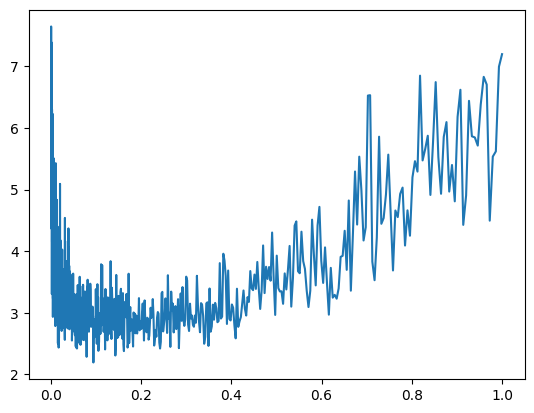

In [259]:
plt.plot(lri,lossi)

In [281]:
lri = []
lossi = []
for i in range(1000):
#forward pass
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))
  
  # forward pass
  emb = C[X[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
  #print(loss.item()) 
    #backward pass
  for p in parameters:
      p.grad = None
  loss.backward()
    #update 
  lr = lrs[i]
  for p in parameters:
      p.data += -lr * p.grad

  # track stats
  lri.append(lre[i])
  #stepi.append(i)
  lossi.append(loss.item())

#Having identified 0.1 as a confident and effective learning rate,
    #the speaker sets this value for further training. They then proceed to run a longer 
    #optimization with 10,000 steps to solidify the results. Additionally, 
    #they plan to apply a learning rate decay by reducing the rate tenfold to 
    #improve convergence.


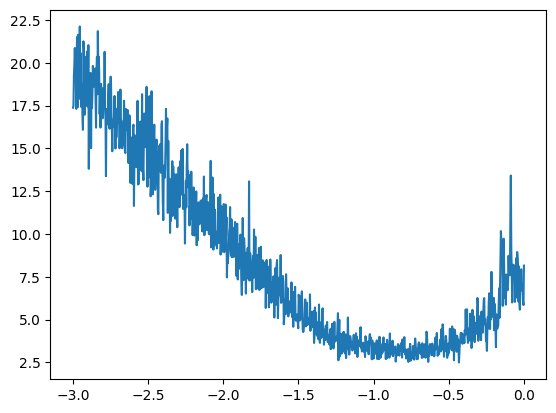

In [272]:
plt.plot(lri,lossi)

In [291]:
lri = []
lossi = []
for i in range(10000):
#forward pass
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))
  
  # forward pass
  emb = C[X[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
  #print(loss.item()) 
    #backward pass
  for p in parameters:
      p.grad = None
  loss.backward()
    #update 
  #lr = lrs[i]
  lr = 0.1 
  for p in parameters:
      p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  #stepi.append(i)
  #lossi.append(loss.item())

In [292]:
emb = C[X] # (32, 3, 10)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.4622, grad_fn=<NllLossBackward0>)

In [ ]:
##Learning rate decay to improve training
#The video explains the process of adjusting the learning rate during neural network training.
#Starting with a learning rate of 0.1 shows improvement, surpassing the bi-gram model's loss of 
#2.45 by achieving about 2.3. It also introduces the concept of learning rate decay,
#where the learning rate is reduced gradually to refine training and improve the model. 
#This approach, although simplified, mimics typical production training strategies
#

In [295]:
lri = []
lossi = []
for i in range(10000):
#forward pass
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))
  
  # forward pass
  emb = C[X[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
  #print(loss.item()) 
    #backward pass
  for p in parameters:
      p.grad = None
  loss.backward()
    #update 
  #lr = lrs[i]
  lr = 0.01 
  for p in parameters:
      p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  #stepi.append(i)
  #lossi.append(loss.item())

In [296]:
emb = C[X] # (32, 3, 10)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.3952, grad_fn=<NllLossBackward0>)

In [ ]:
#The speaker discusses model capacity and overfitting, noting that while the 
#current small neural network achieves a lower loss than the bi-gram model, 
#larger models with more parameters can overfit the training data. Overfitting leads 
#to very low training loss but poor generalization, as the model memorizes training 
#examples rather than learning to generalize. To counter this, datasets are commonly 
#split into training, development (validation), 
#and test sets to properly evaluate model performance on unseen data.

In [ ]:
#Dataset splitting: train, dev, test

#The data is split into training, validation (dev), and test sets, 
#typically with around 80% for training and 10% each for validation and test. 
#The training set is used to optimize model parameters via methods like gradient descent. 
#The validation set is used for tuning hyperparameters such as hidden layer size, 
#embedding dimensions, and regularization strength. Various hyperparameter configurations 
#are tested to find the best performing model on the validation set.
# training split, dev/validation split, test split
# 80%, 10%, 10%

#The test set is reserved for final evaluation and should only be used sparingly to 
#avoid overfitting. Frequent evaluation on the test set risks indirectly training on it, 
#which can bias model performance. During development, training occurs solely on the training 
#set, 
#with hyperparameters tuned on the validation set, and only occasional testing on the test set.

In [305]:
# build the dataset
def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
      
      #print(w)
      context = [0] * block_size
      for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append
      
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

    
import random 
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev =build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:]) 

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [306]:
#len(words)
#The function further slices the shuffled words into training, validation, and test examples, 
#creating corresponding x and y arrays for each split. The number of examples per split is 
#printed to confirm the sizes, 
#with clear separation of data for training, development, and testing phases

#The training process begins using only the training subsets x_train and y_train.
#Training neural networks can be time-consuming and is often done asynchronously. 
#Initially, the learning rate was set too low, but adjusting it to 0.01 speeds training. 
#The model is then evaluated on the validation set, showing a current validation loss 
#around 2.3 after training on 10,000 examples.

In [301]:
#n1

25626

In [302]:
#n2

28829

In [303]:
#n2-n1

3203

In [304]:
#len(words) -n2

3204

In [ ]:

# ------------ now made respectable :) ---------------


In [361]:

Xtr.shape, Ytr.shape # dataset

(torch.Size([182580, 3]), torch.Size([182580]))

In [389]:

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [390]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [391]:
for p in parameters:
  p.requires_grad = True

In [392]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [393]:
lri = [] 
lossi = []
for i in range(10000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.01 
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  #stepi.append(i)
  #lossi.append(loss.log10().item())

#print(loss.item())

In [394]:
print(loss.item())

2.353771924972534


In [397]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.5688, grad_fn=<NllLossBackward0>)

In [398]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.5610, grad_fn=<NllLossBackward0>)

In [440]:

#The validation loss is measured on examples not seen during training, showing the model generalizes 
#reasonably rather than memorizing training data. Both training and validation losses are 
#similar, indicating underfitting since the model hasn't memorized the dataset nor shows 
#signs of overfitting, suggesting it needs more capacity or training.

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [441]:
sum(p.nelement() for p in parameters) # number of parameters in total

10281

In [442]:
for p in parameters:
  p.requires_grad = True

In [443]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [444]:
#Scaling model size and underfitting issues
#The speaker discusses increasing the size of a neural network to improve performance by 
#scaling up the hidden layer from 100 to 300 neurons, thereby increasing the total 
#parameters from around 3,000 to 10,000. They initialize the larger network and set up 
#tracking for both loss and training steps, planning to train for 30,000 iterations.

#The training process is monitored by plotting training steps against loss, showing noise due 
#to mini-batch optimization. The speaker notes the network has not yet converged, likely 
#because the larger model requires more training. They consider the training batch size may 
#be too small, causing excessive noise, and suggest increasing it for steadier gradient descent.

#The video demonstrates splitting the dataset into training, validation, and test sets.
#A function is created to build input (x) and target (y) tensors from a list of words. 
#The words are shuffled randomly before splitting. Index calculations determine how many 
#examples go into each split, roughly 25,000 for training and 3,000 for validation from 
#a total of around 32,000 words.


lri = [] 
lossi = []
stepi = []
for i in range(30000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  #lr = 0.1 
  #lr = 0.05
  lr = 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

In [445]:
print(loss.item())

2.5064218044281006


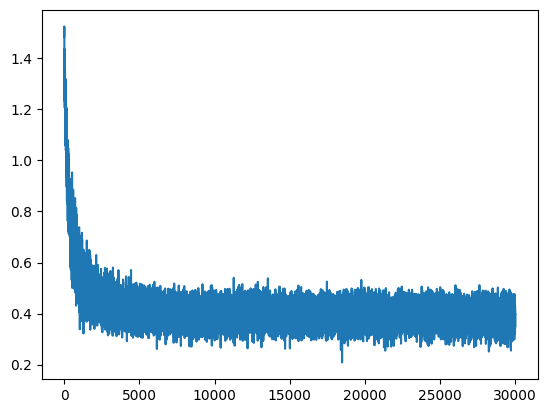

In [446]:
#Further training is done with adjustments, such as decreasing the learning rate to 
#improve convergence. Despite the larger network expected to reduce underfitting and 
#lower loss, improvements are minimal. The speaker speculates that the bottleneck might
#be the 2-dimensional embeddings, which are limiting the network's capacity to represent
#information effectively.

plt.plot(stepi,lossi)

In [447]:
#The speaker plans to visualize the character embedding vectors before increasing their 
#dimension beyond two, as higher dimensions would make visualization difficult. 
#Although minor progress has been made in reducing loss, gains are limited at this stage.

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.4678, grad_fn=<NllLossBackward0>)

In [448]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.4640, grad_fn=<NllLossBackward0>)

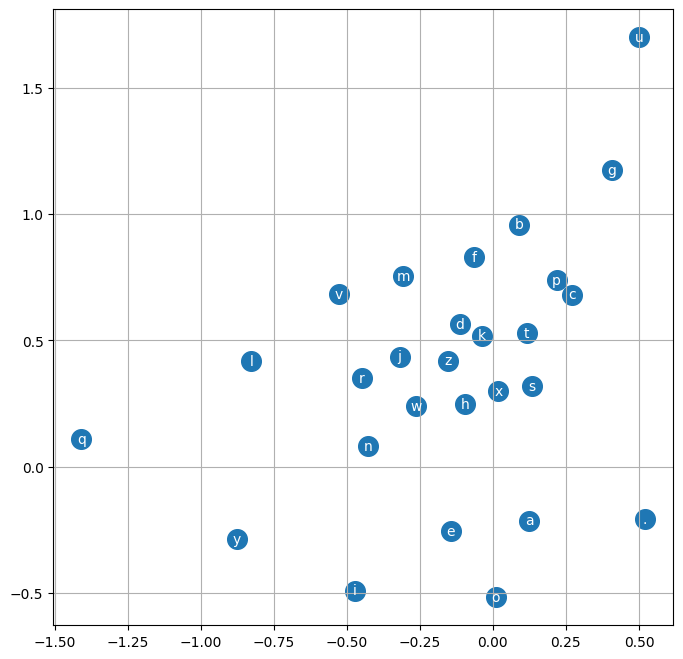

In [439]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
#The segment discusses the analysis of character embeddings trained by a neural network,
#which currently have a size of two. This allows the embeddings to be visualized in two 
#dimensions, revealing that the network clusters similar characters together, such as vowels
#being grouped closely. Outliers like the letter 'q' and the period character have distinct 
#embeddings, indicating special treatment by the network. 
#Overall, the embeddings show meaningful structure rather than randomness after training.
#Since the current two-dimensional embeddings may be limiting model performance and causing 
#underfitting, the plan is to increase the embedding size to ten dimensions. Although this will
#prevent direct visualization, the larger embeddings should provide the neural network with 
#greater representational capacity. The new embedding layer will thus have 30 input features,
#calculated as 3 times 10, aiming to improve the model's results.

plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [473]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [474]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [475]:
for p in parameters:
  p.requires_grad = True

In [476]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [477]:
lri = [] 
lossi = []
stepi = []

In [478]:

for i in range(50000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  #lr = 0.1 
  #lr = 0.05
  #lr = 0.1
  lr = 0.01 
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())


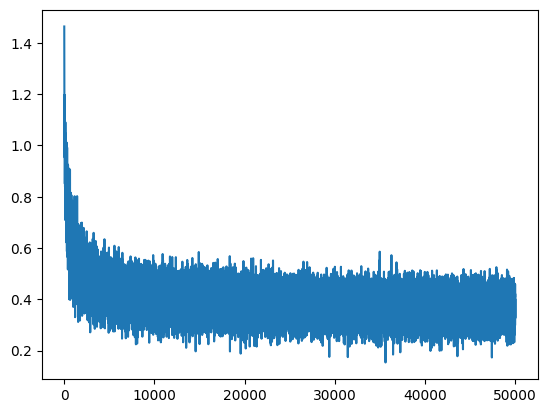

In [482]:
plt.plot(stepi,lossi) #lr 0.01

#Increasing embedding and hidden layer size
#The speaker discusses modifying a neural network by reducing the hidden layer size from 
#300 to 200 neurons, resulting in about 11,000 parameters. They emphasize avoiding hardcoding
#values like the number of iterations, which was set to 50,000, and the learning rate,
#initially set at 0.1. Instead of logging the raw loss, they propose logging the 
#logarithm of the loss to produce cleaner loss curves, improving visualization by smoothing 
#the typical sharp drop seen in loss plots.

#The training loss is observed to be noisy due to the small mini-batch size, 
##with a total loss around 2.3 on the training set and 2.38 on the dev set. 
#The speaker experiments by lowering the learning rate by a factor of ten and 
#continuing training for another 50,000 iterations. They acknowledge that these 
#hyperparameter choices are somewhat arbitrary and not typical of production settings,
#where systematic tuning and multiple experiments are performed to find
#optimal learning rates and decay schedules.

#After further training, training and validation losses improve slightly to approximately 
#2.17 and 2.2, respectively, indicating potential initial overfitting as the model becomes 
#better. The speaker suggests running more experiments to find the best hyperparameters and 
#emphasizes that in practice, the best dev set performance would guide model selection.
#The final 
#selected model would then be evaluated once on the test set to report the official performance


In [ ]:
plt.plot(stepi,lossi)

In [469]:
#The speaker plans to visualize the character embedding vectors before increasing their 
#dimension beyond two, as higher dimensions would make visualization difficult. 
#Although minor progress has been made in reducing loss, gains are limited at this stage.

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2360, grad_fn=<NllLossBackward0>)

In [470]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2975, grad_fn=<NllLossBackward0>)

In [483]:
#With the current training setup, the loss stabilizes around 2.16 on training and
#2.19 on development. The speaker notes multiple avenues for continuing work, 
#including further tuning optimization parameters, adjusting neural network size, 
#or increasing input size by considering more characters instead of just three. 
#A code change to run 200,000 training steps is mentioned, indicating ongoing experimentation.

In [484]:
#Final training results and next steps
#The instructor explains the optimization approach beginning with a learning 
#rate of 0.1 for the first 100,000 iterations, then decreasing it to 0.01 for 
#the next 100,000. The best validation loss achieved in recent training is 2.17.
#Viewers are encouraged to improve upon this result by adjusting multiple hyperparameters,
#such as the number of neurons in the hidden layer, the embedding dimensionality,
#the input context size, optimization details like learning rate schedule and batch size,
#to potentially enhance both convergence speed and final loss.
#Additionally, the instructor recommends reading a related 19-page research paper, 
#which provides further ideas for improving the model.

In [486]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [487]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [488]:
for p in parameters:
  p.requires_grad = True

In [489]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [490]:
lri = []
lossi = []
stepi = []

In [491]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

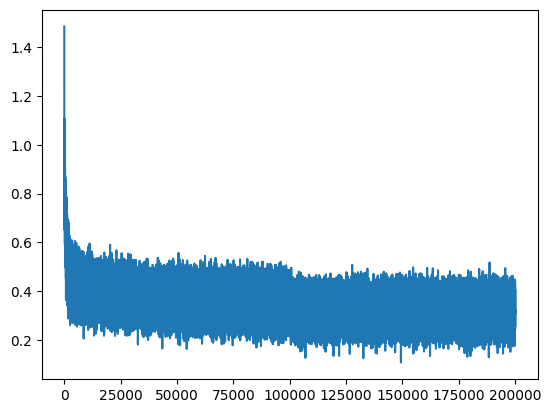

In [499]:
plt.plot(stepi, lossi)

In [500]:

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1302, grad_fn=<NllLossBackward0>)

In [501]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1732, grad_fn=<NllLossBackward0>)

In [504]:
context = [0] * block_size
C[torch.tensor([context])].shape # below section

torch.Size([1, 3, 10])

In [505]:
#Sampling from trained model and examples
#The segment explains how to sample from a language model by generating 20 
#samples starting with a context of all dots. The process involves embedding 
#the current context using an embedding table, projecting the embedding into a 
#hidden state, and calculating logits. These logits are converted into probabilities 
#using a softmax function that ensures numerical stability. Then, multinomial sampling is applied to select the next token index, 
#which is appended to the context for the next iteration.
#After generating samples, the tokens are decoded back to strings to visualize the output. 
#The resulting words are more coherent and name-like, indicating that the model's 
#performance has improved but still has room for enhancement. 
#The speaker briefly mentions including some bonus content before concluding the section.
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmahzatelle.
khirgy.
kheatl.
halayson.
mahnel.
delyah.
jareli.
nellara.
chaiiv.
kaleigh.
ham.
evin.
quint.
sulin.
alian.
quin.
elo.
dearynn.
jace.
pirudi.
